In [277]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import pygmt
from pyrolite.util.time import Timescale
ts = Timescale()
import os
import rioxarray as rio
from scipy.ndimage import gaussian_filter
from scipy.stats import sem 
import shutil
import skimage
import sys
import xarray as xr
import xesmf as xe


from code import pbdb_dataset, paleoRotator, climateScenario, getBiomodSDMs, present_day_distribution
from importlib import reload
reload(pbdb_dataset)
reload(paleoRotator)
reload(climateScenario)
reload(getBiomodSDMs)
reload(present_day_distribution)

# Paths
pbdb_data_path = 'data/fossils/scleractinian_pbdb.csv'
pbdbDataset = pbdb_dataset.PBDBDataset(pbdb_data_path).basic_df()

pared_data_path = 'data/fossils/pared_danijela.csv'
paredDF = pbdb_dataset.paredDataset(pared_data_path).basic_df()

ebyte_rotationFile = f'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/CombinedRotations.rot'
ebyte_static_polygon_file = f'data/reconstructions/Zahirovic_etal_2022_GDJ_NNR/StaticGeometries/StaticPolygons/Global_EarthByte_GPlates_PresentDay_StaticPlatePolygons.shp'
eByteRecon = paleoRotator.PaleoRotator(ebyte_rotationFile, ebyte_static_polygon_file)

scotese_rotationFile = '/Applications/GPlates_2.5.0/GeoData/FeatureCollections/AltPlateReconstructions/Scotese_PALEOMAP_GlobalPlateModel/PALEOMAP_PlateModel.rot'
scotese_static_polygon_file = "/Applications/GPlates_2.5.0/GeoData/FeatureCollections/AltPlateReconstructions/Scotese_PALEOMAP_GlobalPlateModel/PALEOMAP_TerranePolygons.gpmlz"
scoteseRecon = paleoRotator.PaleoRotator(scotese_rotationFile, scotese_static_polygon_file)


ebyteSimulationDirectory = 'data/climate_simulations/earthByte_paleomag'
scoteseSimulationDirectory = 'data/climate_simulations/scotese'
co2s = [sim.split('_')[-1] for sim in os.listdir(ebyteSimulationDirectory) if not os.path.isfile(os.path.join(ebyteSimulationDirectory, sim))]
co2s = sorted([c for c in co2s if c.isdigit()], key=int) + [c for c in co2s if not c.isdigit()]
ages = np.arange(0,260,10)

merdith_file = 'data/paleotemperature_datasets/Merdith2024/ALL_ON_r=1000_2025Feb13.obj'
pySCION_classes_path = 'data/paleotemperature_datasets/Merdith2024/pySCION_classes.py'
scotese_file = 'data/paleotemperature_datasets/scotese2021_paleotemps/Part 4. Phanerozoic_Paleotemperature_Summaryv4.xlsx'
phanDA_file = 'data/paleotemperature_datasets/PhanDA_GMSTandCO2_percentiles.csv'
grossmann_file = 'data/paleotemperature_datasets/paleotemperatures_Grossman_Joachimski_2022/41598_2022_11493_MOESM7_ESM.xlsx'

mm = 1/25.4  # mm in inches

plt.rcParams['font.size']=6.5
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Helvetica']

# pyGMT config variables
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP='ddd:mm:ssF')
pygmt.config(MAP_FRAME_PEN='thin')
pygmt.config(FONT='5.5p,Helvetica,black')
pygmt.config(FONT_TAG='9.3p,Helvetica,black')
pygmt.config(FONT_LABEL='6.5p,Helvetica,black')
pygmt.config(FONT_ANNOT_PRIMARY="6.5p")
pygmt.config(FONT_ANNOT_SECONDARY="5.5p")
pygmt.config(FONT_HEADING='7p,Helvetica,black')
pygmt.config(FONT_TITLE='7p,Helvetica,black') #The title above subplots
pygmt.config(PROJ_LENGTH_UNIT='cm')
pygmt.config(MAP_HEADING_OFFSET='-0.2c') # Dist between plots and main heading
pygmt.config(MAP_GRID_PEN_PRIMARY='0.6p,grey')
pygmt.config(COLOR_NAN="grey")

# pyGMT mapping defaults
# proj="W0/15c" # Mollweide
proj="Q16" # Cylindrical equidistant projection
region='d' # d = Global region
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
w="1.5p,black" # default pen settings for drawing plate boundaries etc
bar="JBC+o0/-1.5" # Default position and width for the colorbar

/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/code/pbdb_dataset.py:20: DtypeWarning: Columns (3,56,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(self.csv_path, skiprows=list(range(0,18)))
/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/code/pbdb_dataset.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['longit'] = df['longit'].round(2)
/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/code/pbdb_dataset.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [278]:
ebyteScenario = climateScenario.ClimateScenario(ebyteSimulationDirectory, co2s, ages)
scoteseScenario = climateScenario.ClimateScenario(scoteseSimulationDirectory, co2s, ages)

## scenario figure

In [279]:
# ebyte GMST
ebyte_modelGMST_df, ebyte_GMSTcurve_df = ebyteScenario.get_paleotemperature_df(var='puma_temperature_surface_air', merdith_file=merdith_file, pySCION_classes_path=pySCION_classes_path, scotese_file=scotese_file, phanDA_file=phanDA_file)
ebyte_matchingScenarios = ebyteScenario.get_matching_scenario(ebyte_modelGMST_df, ebyte_GMSTcurve_df)

# # scotese GMST
scotese_modelGMST_df, scotese_GMSTcurve_df = scoteseScenario.get_paleotemperature_df(var='puma_temperature_surface_air', merdith_file=merdith_file, pySCION_classes_path=pySCION_classes_path, scotese_file=scotese_file, phanDA_file=phanDA_file)
scotese_matchingScenarios = scoteseScenario.get_matching_scenario(scotese_modelGMST_df, scotese_GMSTcurve_df)

# ebyte tropical SST
ebyte_modelSST_df = ebyteScenario.get_global_goldstein_aves(var='temp', tropical=True)
ebyte_SSTcurve_df = ebyteScenario.process_grossman(grossmann_file)
ebyte_matchingScenarios_SST=ebyteScenario.get_matching_scenario(ebyte_modelSST_df,ebyte_SSTcurve_df)

# scotese SST
scotese_modelSST_df = scoteseScenario.get_global_goldstein_aves(var='temp', tropical=True)
scotese_SSTcurve_df = scoteseScenario.process_grossman(grossmann_file)
scotese_matchingScenarios_SST=scoteseScenario.get_matching_scenario(scotese_modelSST_df,scotese_SSTcurve_df)


data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/50Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/90Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_200/40Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_Pa

grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/0Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
/Users/jono/opt/anaconda3/envs/paleoreef/lib/python3.12/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing 5.5402045249938965 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_s

data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/50Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/90Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/100Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/110Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/130Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_100/140Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jon

data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_200/40Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work
data/climate_simulations/earthByte_paleomag/2024-07-23_realigned_earthbyte_paleo_PaleomagRef_200/50Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work


...

grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/50Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/60Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudSto

data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/90Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/140Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/150Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudS

data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/170Ma_nc_outputs/gold_spn_av_0000003000_00.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/220Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/plasimGenieWorkflows/data/climate_simulations/scotese/2024-10-08_realigned_scotese_paleo_shallowSea_fosterCO2/230Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/Library/CloudS

Text(0.5, 0, 'Age (Ma)')

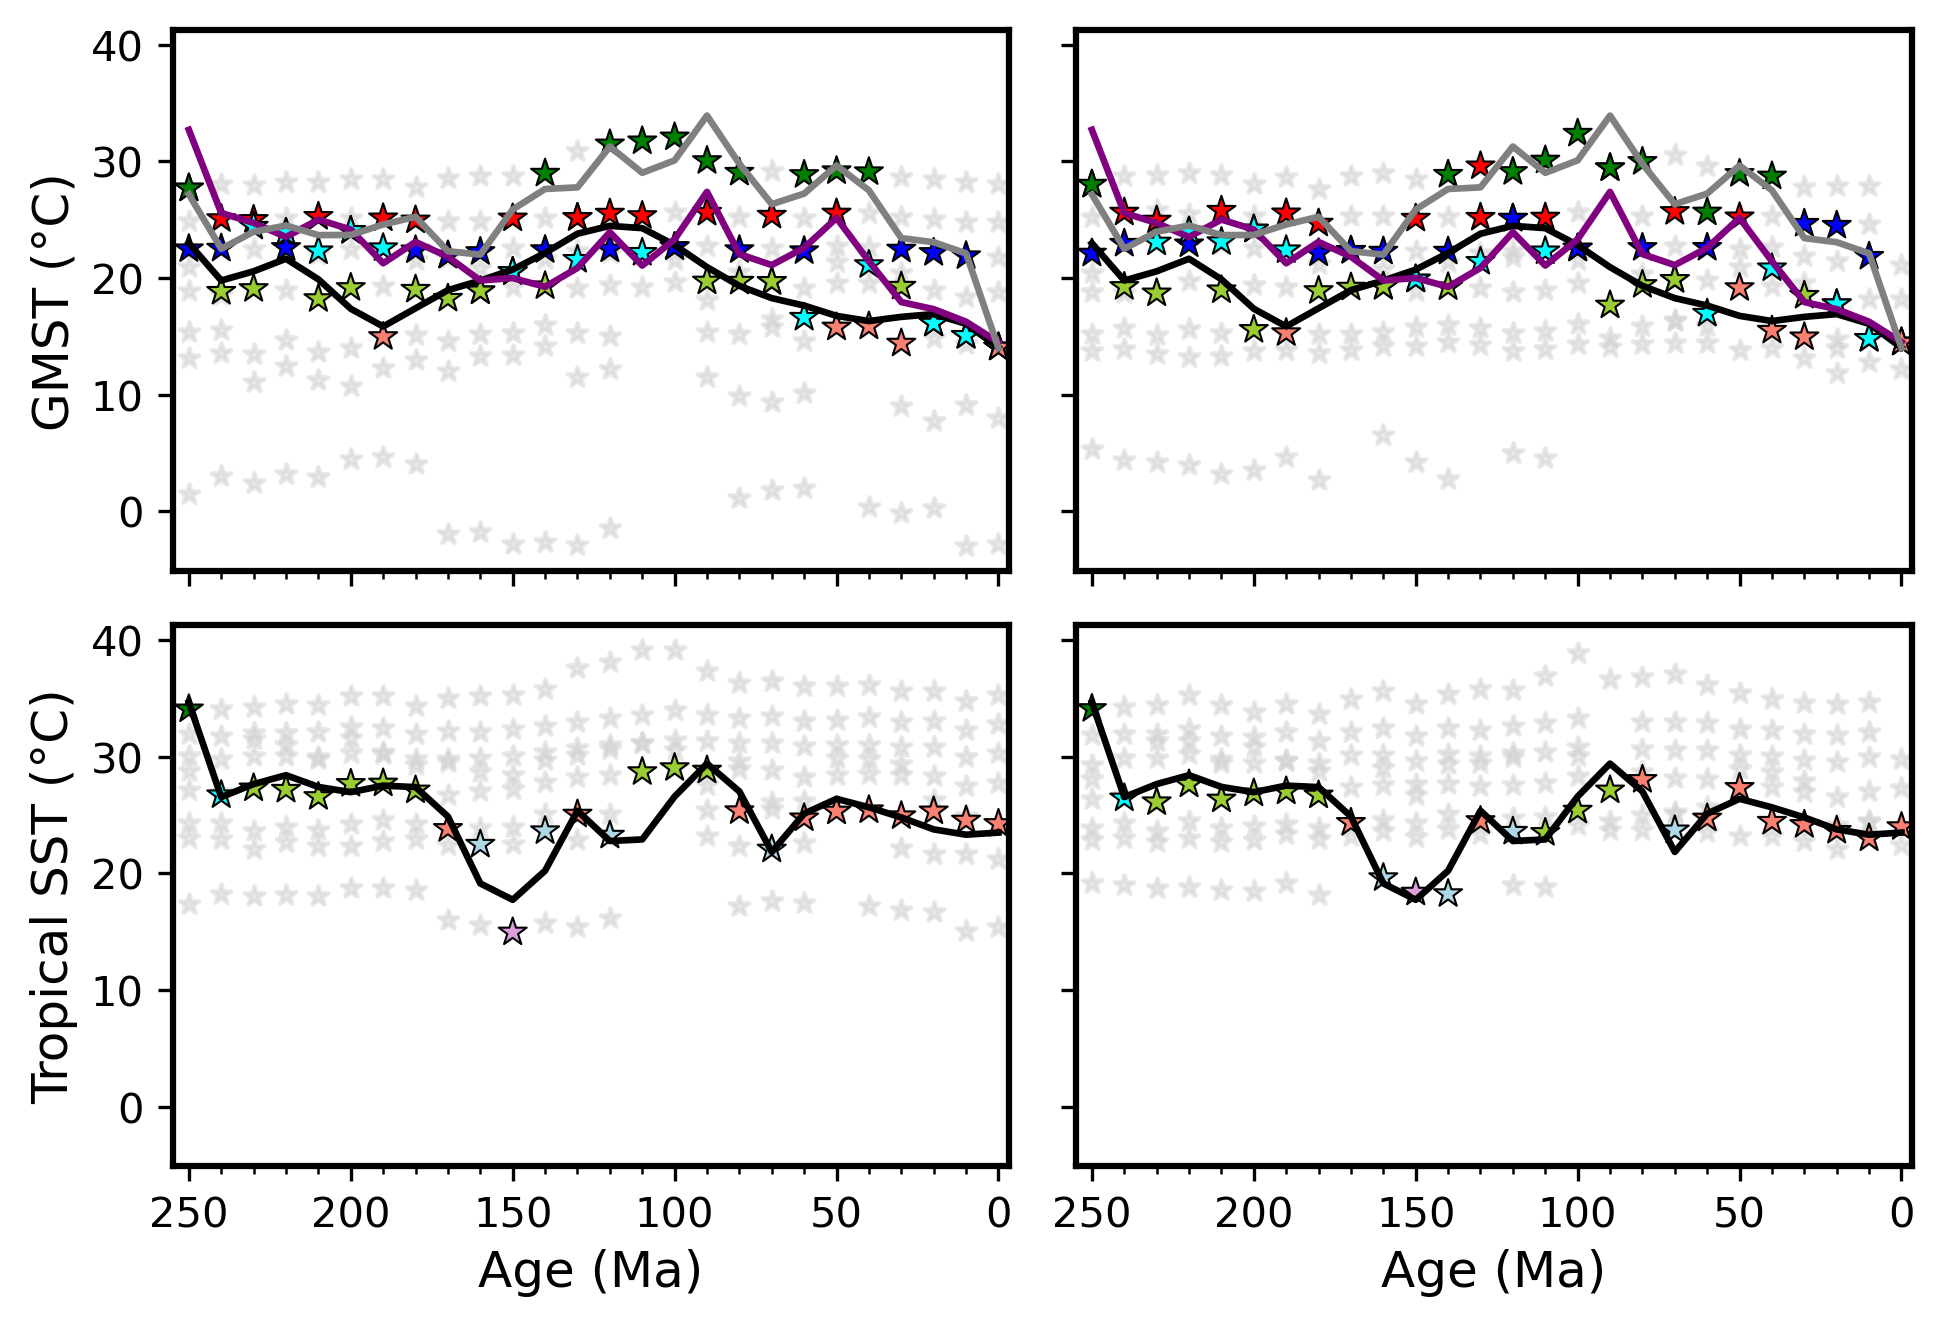

In [280]:
colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']
colourDict = {}
ptempCurveColours =['black','purple','grey']
markers = []
labels = []

for i, co2 in enumerate(co2s):
    colour = colours[i]
    colourDict[co2] = colour
    marker = mlines.Line2D([], [], color=colour, marker='*', linestyle='None', markersize=15, markeredgewidth=0.5, markeredgecolor='black', label=f'{co2}')
    markers.append(marker)

    if co2 == 'fosterCO2':
        label = 'Foster et al. 2017'
    else:
        label = f'{co2} ppm'
    labels.append(label)
# Plot all four figures
fig, axs = plt.subplots(2, 2, figsize=(190*mm,125*mm), dpi=300, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.08, hspace=0.1)  # Reduce horizontal and vertical space between subplots
# Set Y-axis limits
# ax.set_ylim(13, 29)
axs[0,0].set_xlim(255,-3.2)
axs[0,0].set_xticks(np.arange(0, 251, 50))
axs[0,0].set_xticks(np.arange(0, 251, 10), minor=True)
axs[0,0].xaxis.remove_overlapping_locs = False

# Add tick marks for the Y-axis
# ax.set_yticks(np.arange(15, 29, 5))
# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
# ax.yaxis.remove_overlapping_locs = False

for i, co2 in enumerate(co2s): 
    axs[0, 0].scatter(x=ebyte_modelGMST_df.index, y=ebyte_modelGMST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=1, s=25, alpha=0.5)
    axs[0, 1].scatter(x=scotese_modelGMST_df.index, y=scotese_modelGMST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=1, s=25, alpha=0.5)
    axs[1, 0].scatter(x=ebyte_modelSST_df.index, y=ebyte_modelSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=1, s=25, alpha=0.5)
    axs[1, 1].scatter(x=scotese_modelSST_df.index, y=scotese_modelSST_df[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=1, s=25, alpha=0.5)

for i, paleotempCurve in enumerate(ebyte_SSTcurve_df.columns):
    axs[1,0].plot(ebyte_SSTcurve_df.index, ebyte_SSTcurve_df[paleotempCurve], linewidth=1.6, color=ptempCurveColours[i], linestyle='-', label=paleotempCurve.split('_')[0])
    axs[1,1].plot(scotese_SSTcurve_df.index, scotese_SSTcurve_df[paleotempCurve], linewidth=1.6, color=ptempCurveColours[i], linestyle='-', label=paleotempCurve.split('_')[0])

    sstDict_ebyte = {}
    sstDict_scotese = {}
    colours = {}
    for age in ebyte_matchingScenarios.index:
        co2 = ebyte_matchingScenarios.loc[age, paleotempCurve]
        sstDict_ebyte[age] = ebyte_modelSST_df.loc[age, co2]
        colours[age] = colourDict[co2]

        co2 = scotese_matchingScenarios.loc[age, paleotempCurve]
        sstDict_scotese[age] = scotese_modelSST_df.loc[age, co2]

    try:
        axs[1,0].scatter(x=list(sstDict_ebyte.keys()),y=list(sstDict_ebyte.values()), marker='*', facecolors=list(colours.values()), edgecolors='black', linewidths=0.5, s=50)
        axs[1,1].scatter(x=list(sstDict_scotese.keys()),y=list(sstDict_scotese.values()), marker='*', facecolors=list(colours.values()), edgecolors='black', linewidths=0.5, s=50)
    except:
        continue  

for i,paleotempCurve in enumerate(ebyte_GMSTcurve_df.columns):
    # ebyte GMST curve is the paleotemp reconstruction so will be the same fro ebyte and scotese
    axs[0, 0].plot(ebyte_matchingScenarios.index, ebyte_GMSTcurve_df[paleotempCurve], linewidth=1.6, color=ptempCurveColours[i], linestyle='-', label=paleotempCurve.split('_')[0])
    axs[0, 1].plot(ebyte_matchingScenarios.index, ebyte_GMSTcurve_df[paleotempCurve], linewidth=1.6, color=ptempCurveColours[i], linestyle='-', label=paleotempCurve.split('_')[0])

    tempDict_ebyte = {}
    tempDict_scotese = {}
    colours = {}
    for age in ebyte_matchingScenarios.index:
        co2 = ebyte_matchingScenarios.loc[age, paleotempCurve]
        tempDict_ebyte[age] = ebyte_modelGMST_df.loc[age, co2]
        colours[age] = colourDict[co2]

        co2 = scotese_matchingScenarios.loc[age, paleotempCurve]
        tempDict_scotese[age] = scotese_modelGMST_df.loc[age, co2]

    try:
        axs[0,0].scatter(x=list(tempDict_ebyte.keys()),y=list(tempDict_ebyte.values()), marker='*', facecolors=list(colours.values()), edgecolors='black', linewidths=0.5, s=50)
        axs[0,1].scatter(x=list(tempDict_scotese.keys()),y=list(tempDict_scotese.values()), marker='*', facecolors=list(colours.values()), edgecolors='black', linewidths=0.5, s=50)
    except:
        continue

# Set the x and y labels
axs[0, 0].set_ylabel('GMST (°C)', labelpad=3)
axs[1, 0].set_ylabel('Tropical SST (°C)', labelpad=3)
axs[1, 0].set_xlabel('Age (Ma)', labelpad=3)
axs[1, 1].set_xlabel('Age (Ma)', labelpad=3)



## Snapshots of biomod ensemble results

Biomod projection of some key snapshots with EarthByte geographies on the left and Scotese on the right.

In [281]:
def clip2shelves(age, ensemblePath, topoPath, dontClip=False, fuzzyLogic=False):
    """
    Clip the ensemble data to the shelves based on the topography grid.
    """
    if fuzzyLogic:
        ensembleDS = xr.open_dataset(ensemblePath)
        dataEM = ensembleDS.rename({'longitude': 'lon', 'latitude': 'lat'})
        dataEM['wmean'] = dataEM['tempProb']

        if dontClip:
            dataEM['e_mean_shelf'] = dataEM['wmean']
            return dataEM

    else:
        ensembleDS = rio.open_rasterio(ensemblePath, masked=True)

        # Convert ensemble to netcdf
        dataType = ['e_mean','cv','e_median','ca','wmean','ciInf', 'ciSup']

        dataName = ['Mean', 'Coefficient of variation', 'Median', 
                    'Committee averaging score', 'Weighted mean', 
                    'Confidence interval (lower)', 'Confidence interval (upper)']

        k = -1
        for k in range(len(dataType)):
            nda = xr.DataArray(
                            # ensembleDS.isel(band=k).band_data.values,
                            ensembleDS.isel(band=k).values,
                            dims=["lat", "lon"],
                            coords={"lat": ensembleDS.y.values, "lon": ensembleDS.x.values},
                        )

            if k == 0:
                dataEM = nda.to_dataset(name=dataType[k])

            tmp = nda.fillna(0).values
            dataEM[dataType[k]] = (('lat', 'lon'), gaussian_filter(tmp,1))
        if dontClip:
            dataEM['e_mean_shelf'] = dataEM['wmean']
            return dataEM

    # Regrid to 721 x 361
    lon_target = xr.DataArray(np.linspace(-179.25, 179.75, 720), dims='lon')
    lat_target = xr.DataArray(np.linspace(-89.75, 89.75, 360), dims='lat')
    target_grid = xr.Dataset({'lon': lon_target, 'lat': lat_target})

    # Define the regridder
    regridder = xe.Regridder(dataEM, target_grid, method='nearest_s2d')

    # Perform the regridding
    ensembleRegrid = regridder(dataEM)

    # Now bring in the topo grid with shelf data
    tmpGrid = f'tmp_topo_{age}'
    if os.path.exists(tmpGrid):
        os.remove(tmpGrid)

    shutil.copy(topoPath, os.path.join(os.getcwd(), tmpGrid))

    # Open the netCDF file
    topoDS = xr.open_dataset(tmpGrid)
    topoDS = pygmt.grdsample(grid=topoDS['z'],registration='p')

    # # Convert to 0-360
    # topoDS['lon'] = topoDS['lon'].where(topoDS['lon'] >= 0, topoDS['lon'] + 360)
    # topoDS = topoDS.sortby('lon')

    # Define the regridder
    regridder = xe.Regridder(topoDS, target_grid, method='nearest_s2d')
    topoDS = regridder(topoDS)

    ensembleRegrid['topo'] = topoDS

    # Extract the shelves
    grid_data = ensembleRegrid['topo']


    # Make every value an integer
    grid_data = grid_data.astype(int)


    # Create a mask for shallow shelf values
    # shelf = (grid_data >= -1500) & (grid_data < 1)
    # shelf = (grid_data >= -1200) #& (grid_data < 1)
    shelf = (grid_data >= -2000)

    # Set non-shelf values to 0
    grid_data = grid_data.where(shelf, 0)
    grid_data = grid_data.where(~shelf, 1)

    ensembleRegrid['shelf'] = grid_data
    # ensembleRegrid['shelf'].plot()

    ensembleRegrid['e_mean_shelf'] = ensembleRegrid['wmean'].where(ensembleRegrid.shelf == 1)
    # ensembleRegrid['e_mean_shelf'].plot()]

    # Remove tmp files
    for file in os.listdir(os.getcwd()):
        # print(file)
        if file.startswith('tmp'):
            os.remove(file)    

    return ensembleRegrid


In [282]:
def get_contours(ds, lons, lats, var):
    """
    Get contours from a dataset for given longitudes and latitudes and returns contours that trace around the vertices of the grid cells (rather than the mid points)

    This function uses the skimage.measure.find_contours function to find contours in the data.
    """
    # Check if the variable exists in the dataset
    if var not in ds:
        raise ValueError(f"Variable '{var}' not found in the dataset.")

    ## Create a new boolean DataArray with the same dimensions of ds but showing whether each pixel does or does not contain a reef
    #Initialize the 'isReef' variable with zeros in the same dimensions as the dataset
    new_da = xr.zeros_like(ds[var])

    # Convert the paleoreef points to a DataArray since that's easiest to work with the sel function
    points_ds = xr.Dataset({"longitude": ("points", lons), "latitude": ("points", lats),})

    # Also make sure lons are 0-360
    points_ds["longitude"] = points_ds["longitude"] % 360

    # Find the nearest grid cells for all points
    nearest_cells = new_da.sel(longitude=points_ds["longitude"], latitude=points_ds["latitude"], method="nearest")
    
    # Update the 'isReef' variable for all nearest cells
    new_da.loc[{"longitude": nearest_cells["longitude"], "latitude": nearest_cells["latitude"]}] = 1

    contours = skimage.measure.find_contours(new_da.values, level=0.5)

    contour_index = 0
    for contour in contours:
        # Insert a new contour point into the corner of each cell
        i_skip = False
        i = 0
        max_range = len(contour)
        while i < max_range: # Loop over points in the contour
            if i_skip:
                i_skip = False
                continue
            
            y, x = contour[i]
            yp,xp = contour[i-1]
            if y != yp and x != xp:
                if y < yp and x < xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y < yp and x > xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x > xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x < xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
            i += 1
        
        # This bit moves the mini 'steps' that persist for more complex contours
        for i in range(len(contour)):
            y, x = contour[i]
            yp,xp = contour[i-1]
            try:
                yn,xn = contour[i+1]
            except:
                yn,xn = contour[0]
            if y % 1 == 0 and x % 1 == 0:
                if (yn < y and x < xp) or (yn > y and x > xp):
                    contour[i] = [yn, xp]
                if (y < yp and x < xn) or (y > yp and x > xn):
                    contour[i] = [yp, xn]
        
        # Insert back into the original array
        contours[contour_index] = contour
        contour_index += 1

        # Interpolate the contour/pixel coordinates into lats/lons
        contourRealCoords = []
        for contour in contours:
            # Interpolate the contour/pixel coordinates into lats/lons
            ys, xs = contour[:, 0], contour[:, 1]
            lon = ds['longitude'].values
            lat = ds['latitude'].values
            contour_lon = np.interp(xs, np.arange(len(lon)), lon)
            contour_lat = np.interp(ys, np.arange(len(lat)), lat)

            # If there is a value with lon larger than 357, add another point at 360
            # Check if there is a value larger than 357
            if np.any(contour_lon > 357) or np.any(contour_lon < 3):
                for i, lon_val in enumerate(contour_lon):
                    if lon_val > 357 and lon_val < 360:
                        # Add a point at 360
                        contour_lon = np.insert(contour_lon, i+1, 360)
                        contour_lat = np.insert(contour_lat, i+1, contour_lat[i])
                    if lon_val < 3 and lon_val > 0:
                        # Add a point at 0
                        contour_lon = np.insert(contour_lon, i+1, 0)
                        contour_lat = np.insert(contour_lat, i+1, contour_lat[i])
            contourRealCoords.append((contour_lon, contour_lat))

            
    return contourRealCoords

In [283]:
basicParedData = pbdb_dataset.basicLocalityData(paredDF)
paredDF = basicParedData.reconstruct_points(eByteRecon, columnPrefix='eByte_', anchor_plate_id=701701)
paredDF = basicParedData.reconstruct_points(scoteseRecon, columnPrefix='scotese_', anchor_plate_id=0)
basicParedData.selectPoints4Ages(100)
# paredDF

Setting valid time for point 0: maxAge=247.2, minAge=235.0
Setting valid time for point 1: maxAge=247.2, minAge=235.0
Setting valid time for point 2: maxAge=247.2, minAge=235.0
Setting valid time for point 3: maxAge=247.2, minAge=235.0
Setting valid time for point 4: maxAge=247.2, minAge=235.0
Setting valid time for point 5: maxAge=247.2, minAge=235.0
Setting valid time for point 6: maxAge=244.99, minAge=235.0
Setting valid time for point 7: maxAge=244.99, minAge=235.0
Setting valid time for point 8: maxAge=244.99, minAge=235.0
Setting valid time for point 9: maxAge=244.99, minAge=235.0
Setting valid time for point 10: maxAge=244.99, minAge=235.0
Setting valid time for point 11: maxAge=244.99, minAge=235.0
Setting valid time for point 12: maxAge=244.99, minAge=235.0
Setting valid time for point 13: maxAge=244.99, minAge=235.0
Setting valid time for point 14: maxAge=244.99, minAge=235.0
Setting valid time for point 15: maxAge=244.99, minAge=235.0
Setting valid time for point 16: maxAge=

,lon,lat,age,age10,minAge,maxAge,name,eByte_PlateID,eByte_lats,eByte_lons,scotese_PlateID,scotese_lats,scotese_lons
0,259.30,18.48,97.2,100.0,93.9,113.0,3993,215,22.60,299.67,104,17.99,290.50
1,35.20,31.70,97.2,100.0,93.9,100.5,2602,508,9.84,38.73,508,10.42,29.08
2,12.92,41.63,97.2,100.0,93.9,100.5,1331,3071,25.78,26.11,307,24.57,12.26
3,2.32,42.85,97.2,100.0,93.9,100.5,2611,305,34.73,17.83,304,30.30,4.47
4,261.07,22.03,97.2,100.0,93.9,113.0,1178,104,25.70,302.30,104,21.05,293.09
5,13.19,38.11,97.2,100.0,93.9,100.5,4269,323,29.23,19.16,307,21.18,11.20
6,14.17,42.12,97.2,100.0,93.9,100.5,1304,3071,25.71,27.27,307,24.72,13.41
7,13.83,51.00,97.2,100.0,93.9,100.5,2601,375,43.27,27.38,305,40.60,12.87
8,14.48,50.27,97.2,100.0,93.9,100.5,2307,374,42.58,28.01,305,39.91,13.49
9,358.98,45.97,97.2,100.0,93.9,100.5,2600,305,37.79,14.77,305,35.02,0.81


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: proj_earthByte_paleomag_biomodMeans/220.nc -CreefProb.cpt -JQ3.3784i -Rd -V -nb -Xa0i -Ya3.5794i -Bxa120f30 -Bya60f30 -BWrts
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file proj_earthByte_paleomag_biomodMeans/220.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage

No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 357.1875, 36.011329650878906
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 42.1875, 13.849992752075195
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 42.1875, 13.849992752075195
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: proj_earthByte_paleomag_biomodMeans/0.nc -CreefProb.cpt -JQ3.3784i -Rd -V -nb -Xa0i -Ya0i -Bxa120f30 -Bya60f30 -BWrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file proj_earthByte_paleomag_biomodMeans/0.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [INFORMA

No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 8.4375, 41.552284240722656
No valid subset found at 19.6875, 41.552284240722656
No valid subset found at 30.9375, 24.9303169250488

pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: proj_scotese_biomodMeans/0.nc -CreefProb.cpt -JQ3.3784i -Rd -V -nb -Xa3.7082i -Ya0i -Bxa120f30 -Bya60f30 -BwrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file proj_scotese_biomodMeans/0.nc
grdimage [INFORMATION]: Grid x-coordinates after pixel registration adjustment have exactly 360 range
grdimage [INFORMATION]: No range attribute, guessing registration to be pixel
grdimage [INFORMATION]: netCDF gri

No valid subset found at 30.9375, 24.930316925048828


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.


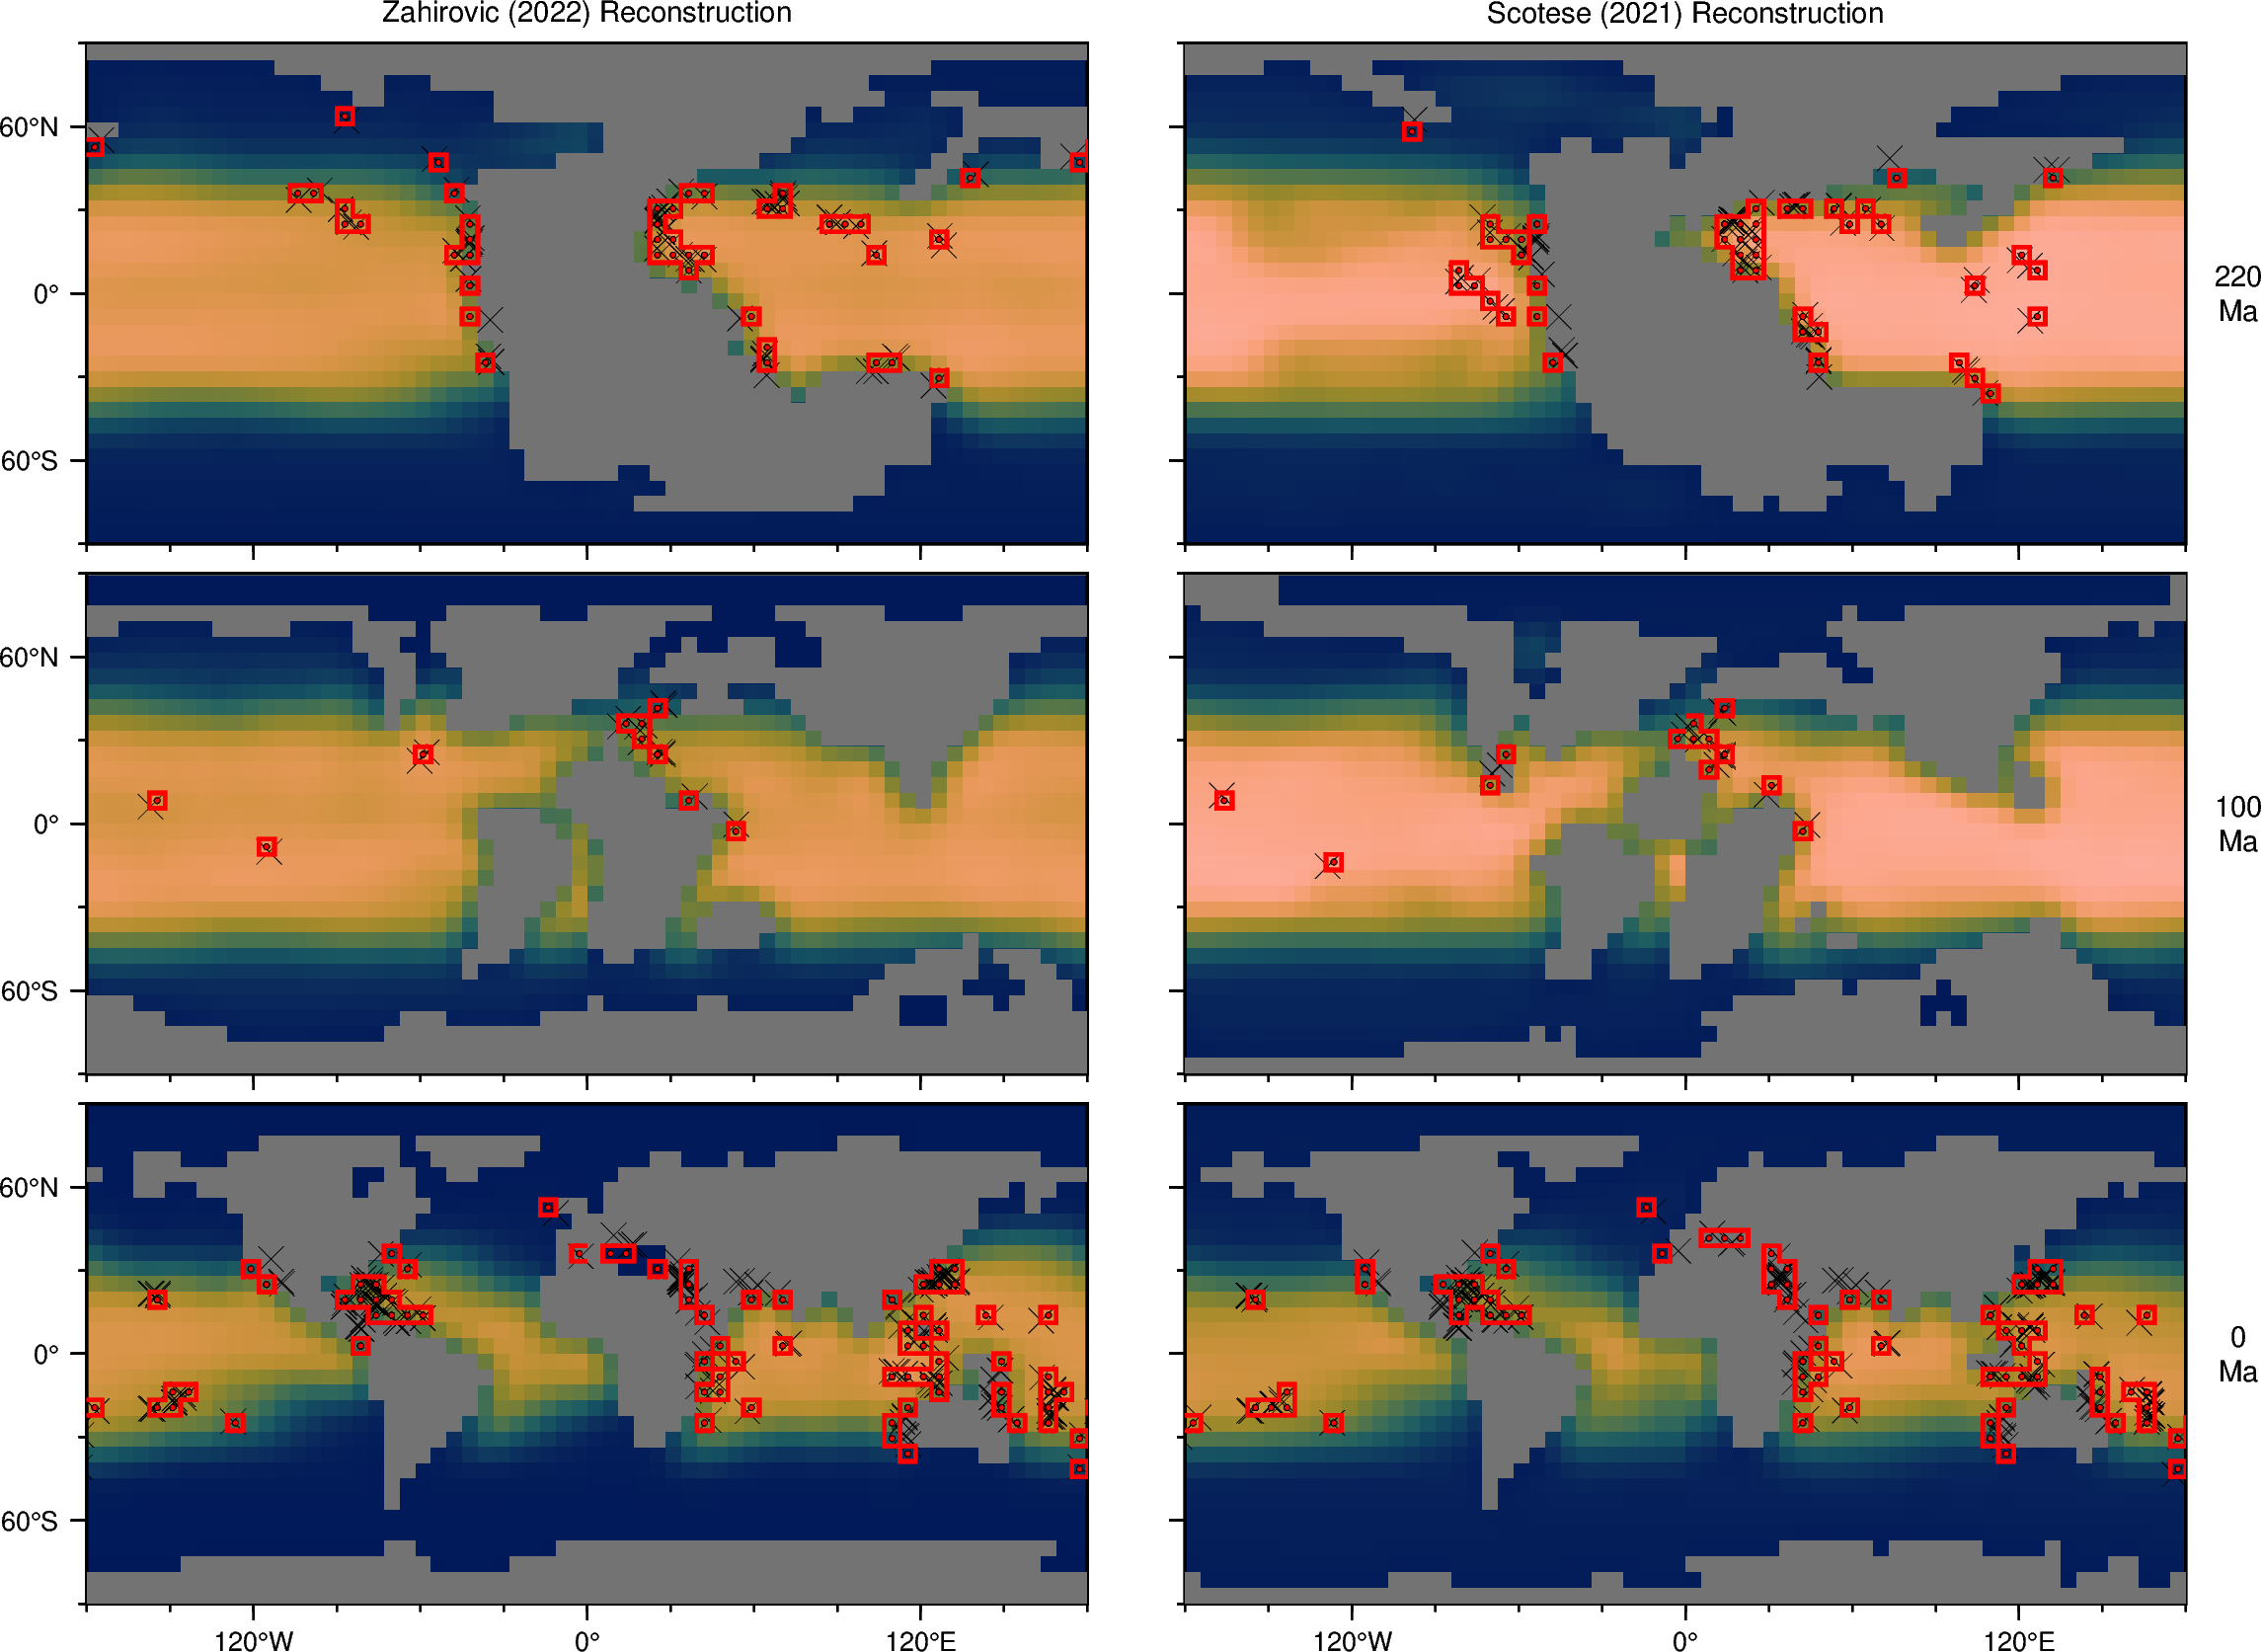

In [284]:
# Figure for a single snapshot
age = 100
ebyteScenario.biomodModelName = 'proj_earthByte_paleomag'
scoteseScenario.biomodModelName = 'proj_scotese'
ebyteTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
ebyteScenario.topoPath = ebyteTopoPath
scoteseScenario.topoPath = scoteseTopoPath

figFolder = 'figures/biomod_projection_earthByte_paleomag'
if os.path.exists(figFolder):
    shutil.rmtree(figFolder)
os.makedirs(figFolder)

def biomod_projection_plot(fig, age, climateScenarioClass, basicParedData, model_prefix='noModelPrefix', figFolder='figures'):
    proj="Q?" # Cylindrical equidistant projection
    region='d' # d = Global region
    pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1200], background=True, output='reefProb.cpt')
    pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)

    modelName = climateScenarioClass.biomodModelName
    ensembleProjection = f'photozoan/{modelName}_{age}Ma/{modelName}_{age}Ma_photozoan_ensemble.tif'

    topo = f'{climateScenarioClass.topoPath}/topo_{age}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)

    select = basicParedData.selectPoints4Ages(age)
    select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
    # select = basicParedData.getNearestModelCellCoordinates(select, 'scotese', climateData)

    # The dataarrays need to be put back into netcdf grids for some reason
    # Remove the FillValue that xarray automaticcaly puts in (stuffs up some of the plotting)
    enc = {"_FillValue": None}
    encoding = {var:enc for var in climateData.coords}
    if os.path.exists('climateData.nc'):
        os.remove('climateData.nc')
    climateData.to_netcdf('climateData.nc',encoding=encoding)

    # The clip2shelves function is used to clip the ensemble data to shallow marine shelves
    # However it also processes the data so best to run the projection data through it even when not clipping
    # Just set dontClip=True if that's the case
    data = clip2shelves(age, ensembleProjection, topo, dontClip=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
    netcdfDir = f'{modelName}_biomodMeans'
    netcdfFile = f'{netcdfDir}/{age}.nc'
    if not os.path.exists(netcdfDir):
        os.makedirs(netcdfDir)
    data['e_mean_shelf'].to_netcdf(netcdfFile)
    # ! gmt grdedit tmp.nc -L+n -Gtmp2.nc

    contours = get_contours(climateData, select[f'{model_prefix}_nearestLons'], select[f'{model_prefix}_nearestLats'], 'landsea')

    fig.grdimage(netcdfFile,projection=proj, region=region, cmap='reefProb.cpt',nan_transparent=False, interpolation='b',verbose=True)
    fig.grdimage('climateData.nc?landsea', projection=proj, region=region, cmap='landGray.cpt', nan_transparent='+z0')

    fig.plot(x=select[f'{model_prefix}_lons'], y=select[f'{model_prefix}_lats'], style="x0.3c", pen="0.07p,black", fill="black", region=region)
    fig.plot(x=select[f'{model_prefix}_nearestLons'], y=select[f'{model_prefix}_nearestLats'], style="c0.05c", pen="0.01p,black", fill="red", region=region)

    for contour in contours:
        # print(contour)
        fig.plot(x=contour[0], y=contour[1], pen="1p,red", projection=proj, region=region)


fig = pygmt.Figure()
nrows = 3 # Number of rows in the subplot
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
pygmt.config(MAP_FRAME_TYPE="plain")
with fig.subplot(
    nrows=nrows,
    ncols=2,
    figsize=("18c", f"{nrows*4.5}c"),
    sharex="b",
    sharey="l",
    margins=["0.35c", "0c"], 
    frame=['WSrt','xa120f30','ya60f30'],
):
    with fig.set_panel(panel=0):
        biomod_projection_plot(fig, 220, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
        fig.text(font='7p', text='Zahirovic (2022) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
    with fig.set_panel(panel=1):
        biomod_projection_plot(fig, 220, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
        fig.text(font='7p', text='Scotese (2021) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'220', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)
    with fig.set_panel(panel=2):
        biomod_projection_plot(fig, 100, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
    with fig.set_panel(panel=3):
        biomod_projection_plot(fig, 100, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
        fig.text(font='7p', text=f'100', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)
    with fig.set_panel(panel=4):
        biomod_projection_plot(fig, 0, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
    with fig.set_panel(panel=5):
        biomod_projection_plot(fig, 0, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
        fig.text(font='7p', text=f'0', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)

fig.show()




## Snapshots of fuzzy logic

pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ3.3784i -Rd -V -nb -Xa0i -Ya3.5794i -Bxa120f30 -Bya60f30 -BWrts
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: No 2-D array in file tmp.nc.  Selecting first 2-D slice in the 4-D array e_mean_shelf
grdimage [INFORMATION]: No 2-D array in file tmp.nc.  Selecting first 2-D slice in the 4-D array e_mean_shelf
grdimage [INFORMATION]: Grid x-coor

No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 357.1875, 36.011329650878906
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 42.1875, 13.849992752075195
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 42.1875, 13.849992752075195
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ3.3784i -Rd -V -nb -Xa0i -Ya0i -Bxa120f30 -Bya60f30 -BWrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: No 2-D array in file tmp.nc.  Selecting first 2-D slice in the 4-D array e_mean_shelf
grdimage [INFORMATION]: No 2-D array in file tmp.nc.  Selecting first 2-D slice in the 4-D array e_mean_shelf
grdimage [INFORMATION]: Grid x-coordinat

No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 8.4375, 41.552284240722656
No valid subset found at 19.6875, 41.552284240722656
No valid subset found at 30.9375, 24.9303169250488

pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
grdimage [INFORMATION]: GMT_Parse_Options: Interval-setting -B options were reordered to appear before axis and frame -B options to ensure proper parsing.
grdimage [INFORMATION]: GMT_Parse_Options: New option order: tmp.nc -CreefProbFuzzy.cpt -JQ3.3784i -Rd -V -nb -Xa3.7082i -Ya0i -Bxa120f30 -Bya60f30 -BwrtS
grdimage [INFORMATION]: Spherical approximation used
grdimage [INFORMATION]: Central meridian not given, default to 0
grdimage [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
grdimage [INFORMATION]: gmt_map_setup perimeter search region: 0/360/-90/90.
grdimage [INFORMATION]: Read header from file tmp.nc
grdimage [INFORMATION]: No 2-D array in file tmp.nc.  Selecting first 2-D slice in the 4-D array e_mean_shelf
grdimage [INFORMATION]: No 2-D array in file tmp.nc.  Selecting first 2-D slice in the 4-D array e_mean_shelf
grdimage [INFORMATION]: Grid x-coor

No valid subset found at 30.9375, 24.930316925048828


pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.
pygmt-session [INFORMATION]: Subplot information file found
pygmt-session [INFORMATION]: Current panel file found
text [INFORMATION]: Processing input text table data
text [INFORMATION]: Spherical approximation used
text [INFORMATION]: Central meridian not given, default to 0
text [INFORMATION]: Map scale is 4664.91 km per cm or 1:4.66491e+08.


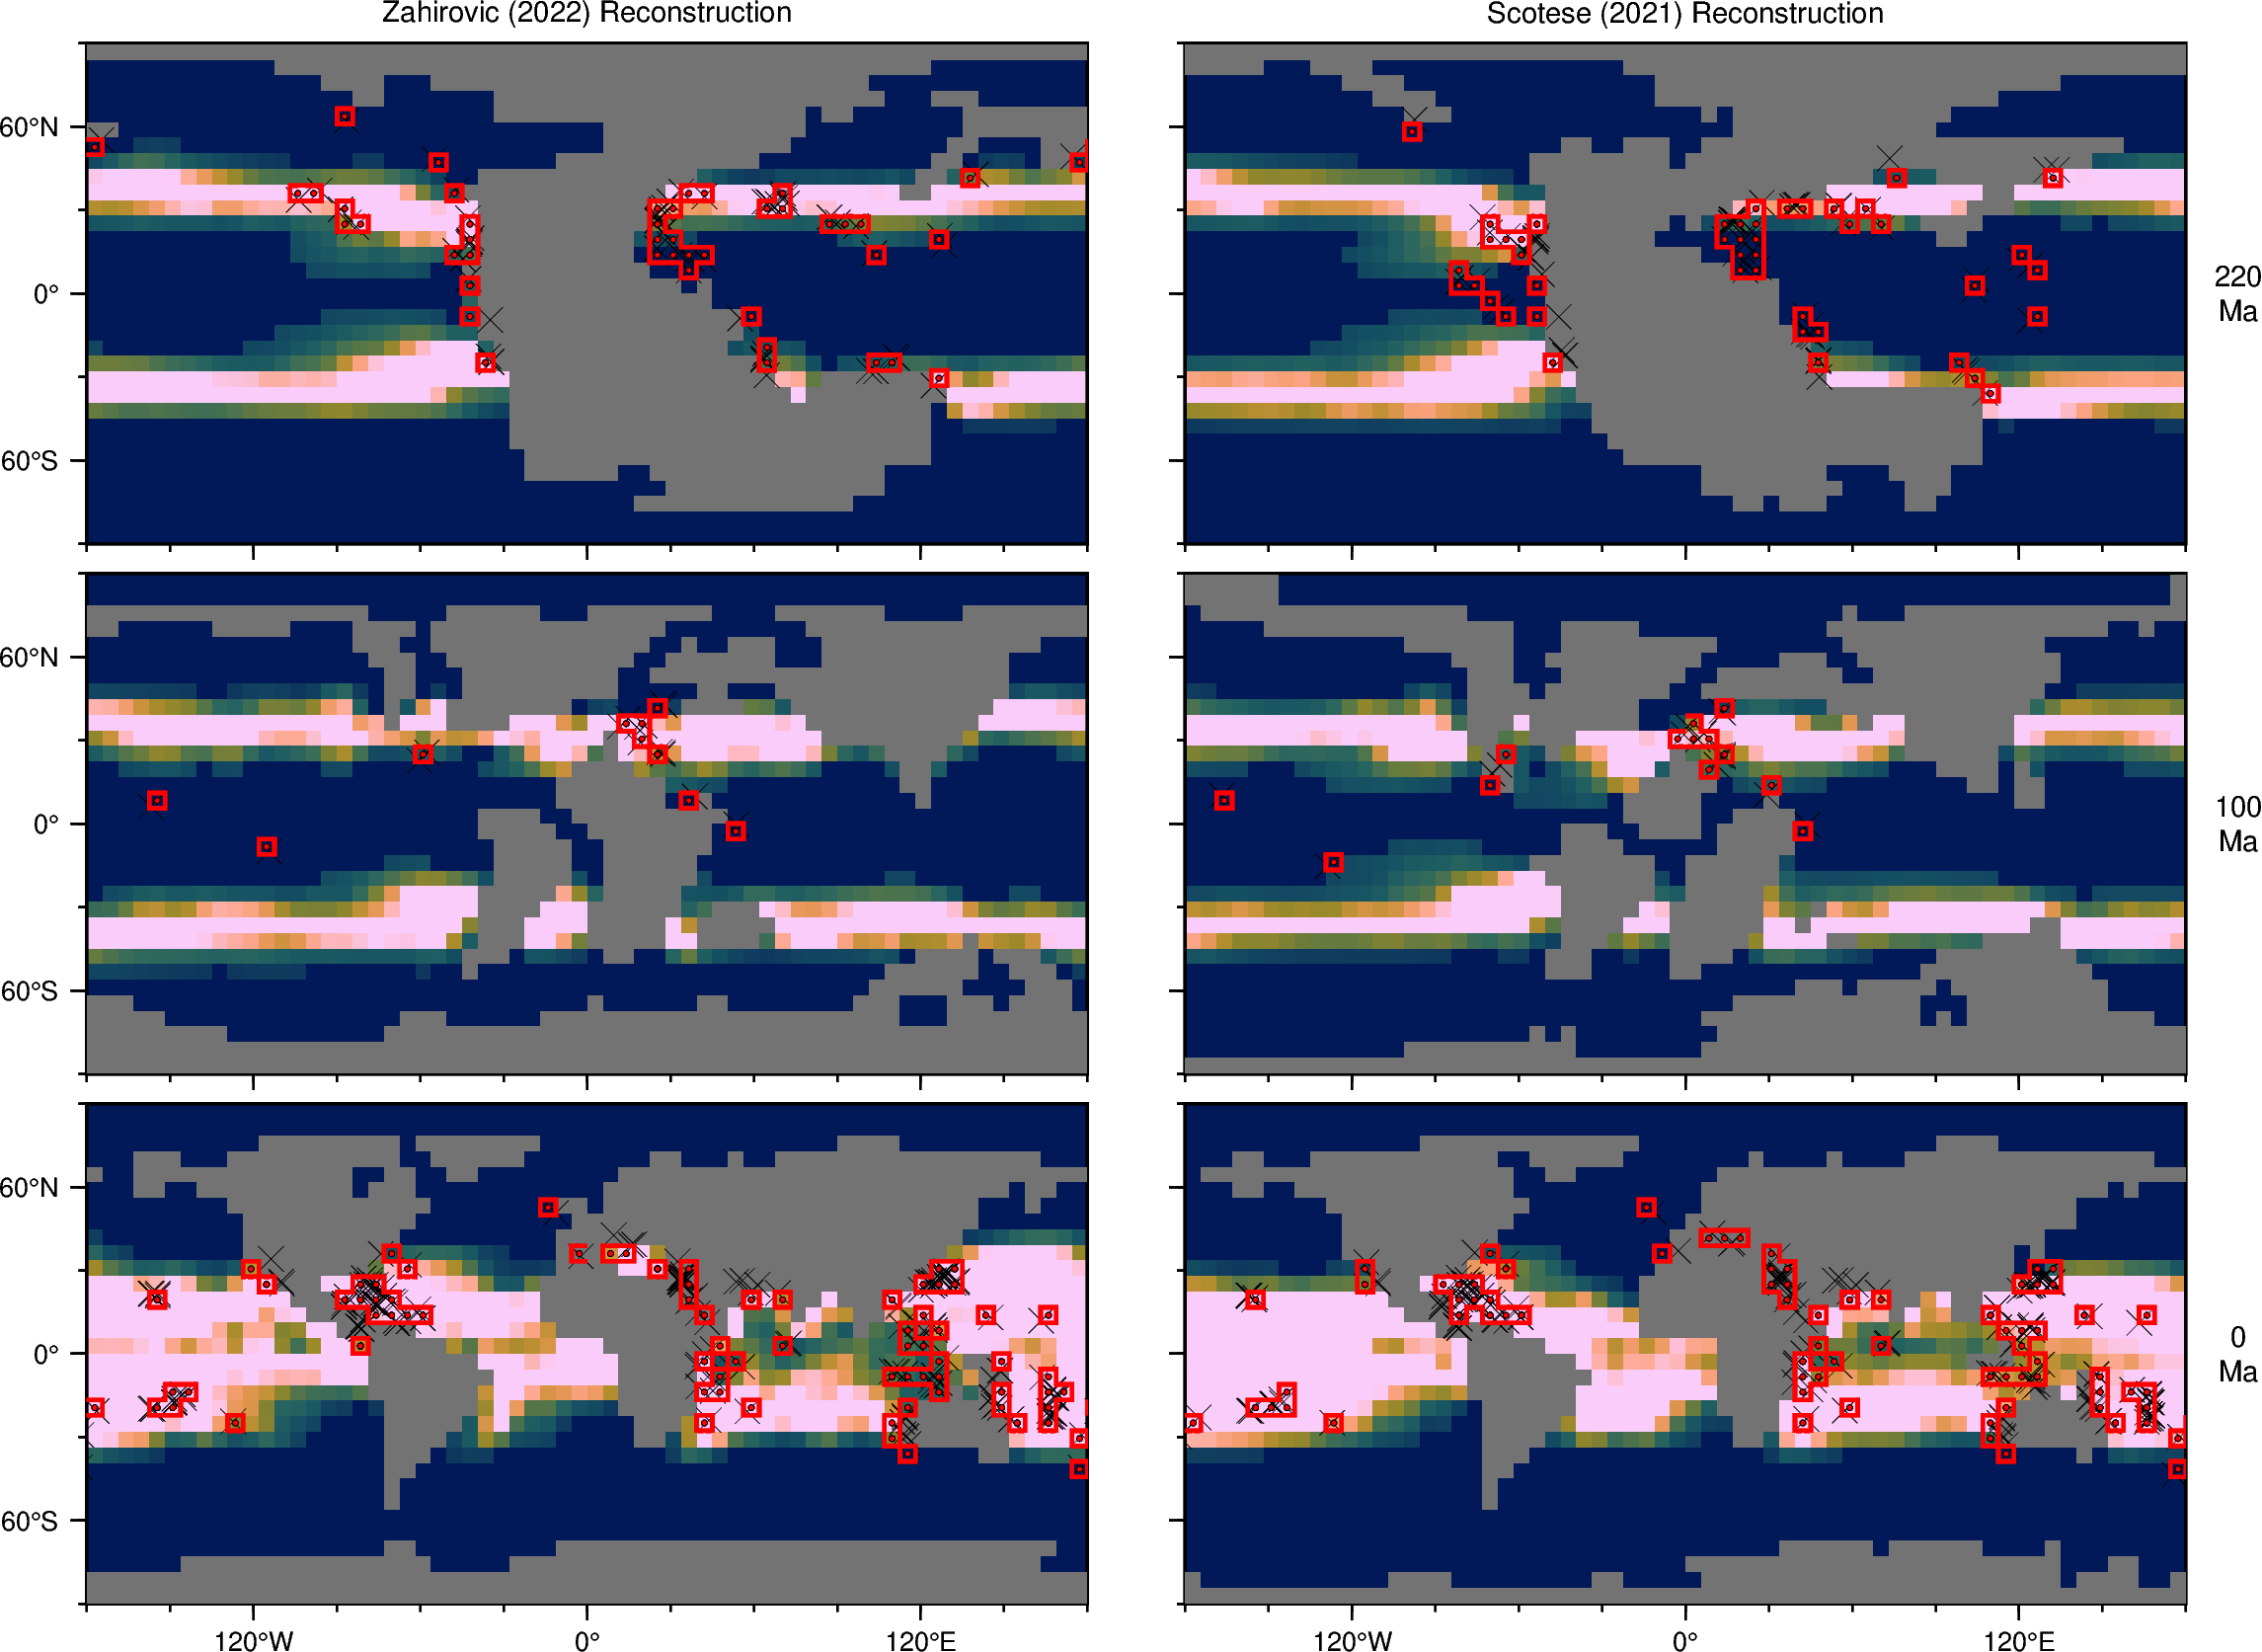

In [285]:
# Figure for a single snapshot
# age = 100
ebyteScenario.fuzzyModelName = 'proj_earthByte_paleomag'
scoteseScenario.fuzzyModelName = 'proj_scotese'
ebyteTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
scoteseTopoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
ebyteScenario.topoPath = ebyteTopoPath
scoteseScenario.topoPath = scoteseTopoPath

figFolder = 'figures/fuzzy_logic_projection_earthByte_paleomag'
if os.path.exists(figFolder):
    shutil.rmtree(figFolder)
os.makedirs(figFolder)

def fuzzy_logic_projection_plot(fig, age, climateScenarioClass, basicParedData, model_prefix='noModelPrefix', figFolder='figures'):
    proj="Q?" # Cylindrical equidistant projection
    region='d' # d = Global region
    pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1], background=True, output='reefProbFuzzy.cpt')
    pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)

    modelName = climateScenarioClass.fuzzyModelName
    fuzzyProjection = f'data/fuzzy_logic_projection/{modelName}/{age}Ma.nc'

    topo = f'{climateScenarioClass.topoPath}/topo_{age}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)

    select = basicParedData.selectPoints4Ages(age)
    select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
    # select = basicParedData.getNearestModelCellCoordinates(select, 'scotese', climateData)

    # The dataarrays need to be put back into netcdf grids for some reason
    # Remove the FillValue that xarray automaticcaly puts in (stuffs up some of the plotting)
    enc = {"_FillValue": None}
    encoding = {var:enc for var in climateData.coords}
    if os.path.exists('climateData.nc'):
        os.remove('climateData.nc')
    climateData.to_netcdf('climateData.nc',encoding=encoding)

    # The clip2shelves function is used to clip the ensemble data to shallow marine shelves
    # However it also processes the data so best to run the projection data through it even when not clipping
    # Just set dontClip=True if that's the case
    data = clip2shelves(age, fuzzyProjection, topo, dontClip=True, fuzzyLogic=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
    data['e_mean_shelf'].to_netcdf('tmp.nc')
    # ! gmt grdedit tmp.nc -L+n -Gtmp2.nc

    contours = get_contours(climateData, select[f'{model_prefix}_nearestLons'], select[f'{model_prefix}_nearestLats'], 'landsea')

    fig.grdimage('tmp.nc',projection=proj, region=region, cmap='reefProbFuzzy.cpt',nan_transparent=False, interpolation='b',verbose=True)
    fig.grdimage('climateData.nc?landsea', projection=proj, region=region, cmap='landGray.cpt', nan_transparent='+z0')

    fig.plot(x=select[f'{model_prefix}_lons'], y=select[f'{model_prefix}_lats'], style="x0.3c", pen="0.07p,black", fill="black", region=region)
    fig.plot(x=select[f'{model_prefix}_nearestLons'], y=select[f'{model_prefix}_nearestLats'], style="c0.05c", pen="0.01p,black", fill="red", region=region)

    for contour in contours:
        # print(contour)
        fig.plot(x=contour[0], y=contour[1], pen="1p,red", projection=proj, region=region)


fig = pygmt.Figure()
nrows = 3 # Number of rows in the subplot
anot_spacing = ['WSrt','xa120f30','ya60f30'] # Annotation settings for global maps
pygmt.config(MAP_FRAME_TYPE="plain")
with fig.subplot(
    nrows=nrows,
    ncols=2,
    figsize=("18c", f"{nrows*4.5}c"),
    sharex="b",
    sharey="l",
    margins=["0.35c", "0c"], 
    frame=['WSrt','xa120f30','ya60f30'],
):
    with fig.set_panel(panel=0):
        fuzzy_logic_projection_plot(fig, 220, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
        fig.text(font='7p', text='Zahirovic (2022) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
    with fig.set_panel(panel=1):
        fuzzy_logic_projection_plot(fig, 220, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
        fig.text(font='7p', text='Scotese (2021) Reconstruction', position="TC", justify="MC", offset="0c/0.27c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'220', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)
    with fig.set_panel(panel=2):
        fuzzy_logic_projection_plot(fig, 100, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
    with fig.set_panel(panel=3):
        fuzzy_logic_projection_plot(fig, 100, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
        fig.text(font='7p', text=f'100', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)
    with fig.set_panel(panel=4):
        fuzzy_logic_projection_plot(fig, 0, ebyteScenario, basicParedData, model_prefix='eByte', figFolder=figFolder)
    with fig.set_panel(panel=5):
        fuzzy_logic_projection_plot(fig, 0, scoteseScenario, basicParedData, model_prefix='scotese', figFolder=figFolder)
        fig.text(font='7p', text=f'0', position="MR", justify="MC", offset="0.45c/0.15c",verbose=True, no_clip=True)
        fig.text(font='7p', text=f'Ma', position="MR", justify="MC", offset="0.45c/-0.15c",verbose=True, no_clip=True)

fig.show()




## Comparison plots -biomod


In [286]:
# Only get the eras where start time is more than 252
eras = ts.Eras[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
epochs = ts.Epochs[ts.Epochs['Start'] < 252].copy().reset_index(drop=True)
# Add a new column with names shortened to the first 3 letters
epochs['ShortName'] = ''
for i, row in epochs.iterrows():
    if epochs.loc[i, 'Start'] - epochs.loc[i, 'End'] < 10:
        epochs['ShortName'].loc[i] = ''
    elif len(epochs.loc[i, 'Name'].split(' ')) > 1:
        word1 = epochs.loc[i, 'Name'].split(' ')[0]
        word2 = epochs.loc[i, 'Name'].split(' ')[1]
        epochs['ShortName'].loc[i] = f"{word1[0]}. {word2[:3]}"
    else:
        epochs['ShortName'].loc[i] = epochs.loc[i, 'Name'][:3]

epochs

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_30051/158872014.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epochs['ShortName'].loc[i] = ''
/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_30051/158872014.py:8: S

,Ident,Name,Level,Start,End,MeanAge,Unc,Eon,Era,Period,Superepoch,Epoch,Age,Aliases,Color,ShortName
0,Phanerozoic-Cenozoic-Quaternary-Holocene,Holocene,Epoch,0.0117,0.0000,0.00585,0.00585,Phanerozoic,Cenozoic,Quaternary,NaN,Holocene,NaN,"[holocene, phanerozoic-cenozoic-quaternary-hol...","(0.996078431372549, 0.9490196078431372, 0.9254...",
1,Phanerozoic-Cenozoic-Quaternary-Pleistocene,Pleistocene,Epoch,2.5800,0.0117,1.29585,1.28415,Phanerozoic,Cenozoic,Quaternary,NaN,Pleistocene,NaN,"[pleistocene, phanerozoic-cenozoic-quaternary-...","(1.0, 0.9490196078431372, 0.6823529411764706, ...",
2,Phanerozoic-Cenozoic-Neogene-Pliocene,Pliocene,Epoch,5.3330,2.5800,3.95650,1.37650,Phanerozoic,Cenozoic,Neogene,NaN,Pliocene,NaN,"[pliocene, phanerozoic-cenozoic-neogene-pliocene]","(1.0, 1.0, 0.6, 1.0)",
3,Phanerozoic-Cenozoic-Neogene-Miocene,Miocene,Epoch,23.0300,5.3330,14.18150,8.84850,Phanerozoic,Cenozoic,Neogene,NaN,Miocene,NaN,"[miocene, phanerozoic-cenozoic-neogene-miocene]","(1.0, 1.0, 0.0, 1.0)",Mio
4,Phanerozoic-Cenozoic-Paleogene-Oligocene,Oligocene,Epoch,33.9000,23.0300,28.46500,5.43500,Phanerozoic,Cenozoic,Paleogene,NaN,Oligocene,NaN,"[oligocene, phanerozoic-cenozoic-paleogene-oli...","(0.9921568627450981, 0.7529411764705882, 0.478...",Oli
5,Phanerozoic-Cenozoic-Paleogene-Eocene,Eocene,Epoch,56.0000,33.9000,44.95000,11.05000,Phanerozoic,Cenozoic,Paleogene,NaN,Eocene,NaN,"[eocene, phanerozoic-cenozoic-paleogene-eocene]","(0.9921568627450981, 0.7058823529411765, 0.423...",Eoc
6,Phanerozoic-Cenozoic-Paleogene-Paleocene,Paleocene,Epoch,66.0000,56.0000,61.00000,5.00000,Phanerozoic,Cenozoic,Paleogene,NaN,Paleocene,NaN,"[paleocene, phanerozoic-cenozoic-paleogene-pal...","(0.9921568627450981, 0.6549019607843137, 0.372...",Pal
7,Phanerozoic-Mesozoic-Cretaceous-Upper,Upper Cretaceous,Epoch,100.5000,66.0000,83.25000,17.25000,Phanerozoic,Mesozoic,Cretaceous,NaN,Upper,NaN,"[upper cretaceous, phanerozoic-mesozoic-cretac...","(0.6509803921568628, 0.8470588235294118, 0.290...",U. Cre
8,Phanerozoic-Mesozoic-Cretaceous-Lower,Lower Cretaceous,Epoch,145.0000,100.5000,122.75000,22.25000,Phanerozoic,Mesozoic,Cretaceous,NaN,Lower,NaN,"[lower cretaceous, phanerozoic-mesozoic-cretac...","(0.5490196078431373, 0.803921568627451, 0.3411...",L. Cre
9,Phanerozoic-Mesozoic-Jurassic-Upper,Upper Jurassic,Epoch,161.5000,145.0000,153.25000,8.25000,Phanerozoic,Mesozoic,Jurassic,NaN,Upper,NaN,"[upper jurassic, phanerozoic-mesozoic-jurassic...","(0.7019607843137254, 0.8901960784313725, 0.933...",U. Jur


In [ ]:
def biomod_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix='noModelPrefix', select=None):
    # proj="Q?" # Cylindrical equidistant projection
    # region='d' # d = Global region
    # pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1200], background=True, output='reefProb.cpt')
    # pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)

    modelName = climateScenarioClass.biomodModelName
    ensembleProjection = f'photozoan/{modelName}_{age}Ma/{modelName}_{age}Ma_photozoan_ensemble.tif'

    topo = f'{climateScenarioClass.topoPath}/topo_{age}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
    if select is None:
        # If no selection is provided, select all points for the given age
        # select = basicParedData.selectPoints4Ages(age)
        select = basicParedData.selectPoints4Epochs(age)
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats
    else:
        select = select # Use this if you already ran this function
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats

    # Just set dontClip=True if that's the case
    data = clip2shelves(age, ensembleProjection, topo, dontClip=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
    netcdfDir = f'{modelName}_biomodMeans'
    netcdfFile = f'{netcdfDir}/{age}.nc'
    if not os.path.exists(netcdfDir):
        os.makedirs(netcdfDir)
    data['e_mean_shelf'].to_netcdf(netcdfFile)

    probs = []
    for i in range(len(select)):
        # Get the nearest model cell coordinates
        nearest_lon = select[f'{model_prefix}_nearestLons'][i]
        nearest_lat = select[f'{model_prefix}_nearestLats'][i]

        # Get the model cell value
        model_value = data['e_mean_shelf'].sel(lon=nearest_lon, lat=nearest_lat, method='nearest').values.item()
        probs.append(model_value)

    select[f'{model_prefix}Probability'] = probs
    return select

eByte_probs = {}
scotese_probs = {}
combinedDF = pd.DataFrame()
for age in np.arange(0,260,10):   
    try:  
        model_prefix='eByte'
        climateScenarioClass = ebyteScenario
        probsDF = biomod_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix=model_prefix)
        eByte_probs[age] = (np.mean(probsDF[f'{model_prefix}Probability']), sem(probsDF[f'{model_prefix}Probability']), len(probsDF[f'{model_prefix}Probability']))
        model_prefix='scotese'
        climateScenarioClass = scoteseScenario
        probsDF = biomod_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix=model_prefix, select=probsDF)
        scotese_probs[age] = (np.mean(probsDF[f'{model_prefix}Probability']), sem(probsDF[f'{model_prefix}Probability']), len(probsDF[f'{model_prefix}Probability']))
        combinedDF = pd.concat([combinedDF, probsDF], ignore_index=True)
    except Exception as e:
        print(f"Error processing age {age}: {e}")
        continue

combinedDF['epoch'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestEpoch(age)['Name'])



No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 36.5625, 8.309966087341309
No valid subset found at 47.8125, 19.39009666442871
No valid subset found at 36.5625, 13.849992752075195
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 13.849992752075195
No valid subset found at 19.6875, 47.093719482421875
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 19.6875, 47.093719482421875
No valid subset found at 14.0625, 36.011329650878906
No valid subset found at 30.9375, 24.930316925048828
No v

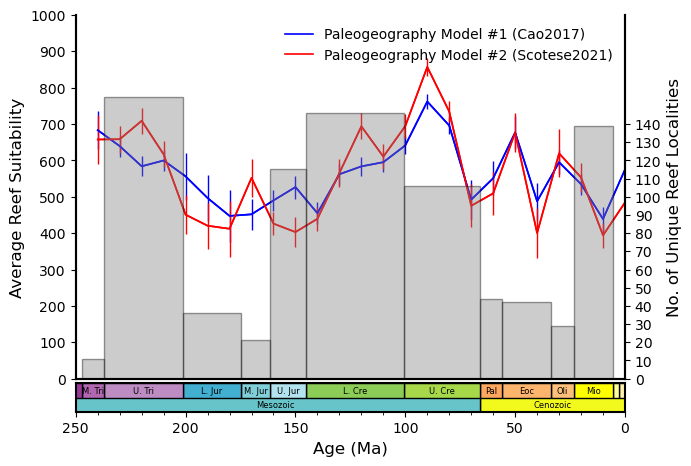

In [323]:
from matplotlib.patches import Rectangle

mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1000)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1010, 100))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
ax.errorbar(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], yerr=list(zip(*eByte_probs.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese2021)')
ax.errorbar(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], yerr=list(zip(*scotese_probs.values()))[1], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

# ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')
ax.xaxis.set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 200)
ax2.set_yticks(np.arange(0, 141, 10))
ax2.set_ylabel('No. of Unique Reef Localities')

# Histogram with epoch bins
uniqueEpochs = combinedDF.groupby('epoch')
counts = {}
for epoch, group in uniqueEpochs:
    counts[epoch] = len(group)

epochBins = [0] + epochs['Start'].tolist()
ax2.hist(combinedDF['age'], bins=epochBins, color='grey', alpha=0.4, label='Paleogeography Model #1 (Cao2017)', edgecolor='black')


# ax2.hist(list(eByte_probs.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*eByte_probs.values()))[2], color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
# ax2.hist(list(scotese_probs.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*scotese_probs.values()))[2], color='red', alpha=0.5, label='Paleogeography Model #2 (Scotese2021)')

ax2.plot([], [], color='black', linestyle=':', label='No. of Unique Reef Localities')

ax.legend(loc='upper right', ncol=1, frameon=False)
# ax2.legend(loc='lower center', ncol=1, frameon=False)

# Hide the right and top spines
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([ax.get_position().x0, 0.04, ax.get_position().width, 0.06], sharex=ax)
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)')
for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )

## Comparison plots - Fuzzy Logic


In [342]:
def fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix='noModelPrefix', select=None):
    # proj="Q?" # Cylindrical equidistant projection
    # region='d' # d = Global region
    # pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1200], background=True, output='reefProb.cpt')
    # pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)

    modelName = climateScenarioClass.fuzzyModelName
    print(f"Processing fuzzy logic probabilities for {modelName} at {age} Ma")
    fuzzyProjection = f'data/fuzzy_logic_projection/{modelName}/{age}Ma.nc'

    topo = f'{climateScenarioClass.topoPath}/topo_{age}_filled.nc'

    # Bring in the climate data just to get the landsea mask in the model resolution
    # So we can just choose a random CO2 scenario
    climateData = xr.open_dataset(f'{climateScenarioClass.climate_simulations['1120']}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc')
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)
    if select is None:
        # If no selection is provided, select all points for the given age
        # select = basicParedData.selectPoints4Ages(age)
        select = basicParedData.selectPoints4Epochs(age)
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats
    else:
        select = select # Use this if you already ran this function
        select = basicParedData.getNearestModelCellCoordinates(select, model_prefix, climateData)
        select = select.drop_duplicates(subset=[f'{model_prefix}_nearestLons', f'{model_prefix}_nearestLats']).reset_index(drop=True) # Remove unique nearestLons and nearestLats

    # Just set dontClip=True if that's the case
    data = clip2shelves(age, fuzzyProjection, topo, dontClip=True, fuzzyLogic=True)

    data['e_mean_shelf'] = xr.where(data['e_mean_shelf']>1200,1200,data['e_mean_shelf']) # To cut off too extreme values
    # data['e_mean_shelf'].to_netcdf('tmp.nc')
    netcdfDir = f'{modelName}_fuzzyLogicMeans'
    netcdfFile = f'{netcdfDir}/{age}.nc'
    if not os.path.exists(netcdfDir):
        os.makedirs(netcdfDir)
    data['e_mean_shelf'].to_netcdf(netcdfFile)

    probs = []
    for i in range(len(select)):
        # Get the nearest model cell coordinates
        nearest_lon = select[f'{model_prefix}_nearestLons'][i]
        nearest_lat = select[f'{model_prefix}_nearestLats'][i]
        print(f"Processing point {i+1}/{len(select)}: ({nearest_lon}, {nearest_lat})")

        # Get the model cell value
        model_value = data['e_mean_shelf'][0][0].sel(lon=nearest_lon, lat=nearest_lat, method='nearest').values.item()
        print(f"Model value for point {i+1}: {model_value}")
        probs.append(model_value)

    select[f'{model_prefix}Probability'] = probs
    return select

eByte_probs = {}
scotese_probs = {}
combinedDF = pd.DataFrame()
for age in np.arange(0,260,10):   
    try:  
        model_prefix='eByte'
        climateScenarioClass = ebyteScenario
        probsDF = fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix=model_prefix)
        eByte_probs[age] = (np.mean(probsDF[f'{model_prefix}Probability']), sem(probsDF[f'{model_prefix}Probability']), len(probsDF[f'{model_prefix}Probability']))
        model_prefix='scotese'
        climateScenarioClass = scoteseScenario
        probsDF = fuzzyLogic_sample_probabilities(age, climateScenarioClass, basicParedData, model_prefix=model_prefix, select=probsDF)
        scotese_probs[age] = (np.mean(probsDF[f'{model_prefix}Probability']), sem(probsDF[f'{model_prefix}Probability']), len(probsDF[f'{model_prefix}Probability']))
        combinedDF = pd.concat([combinedDF, probsDF], ignore_index=True)
    except Exception as e:
        print(f"Error processing age {age}: {e}")
        continue

combinedDF['epoch'] = combinedDF['age'].apply(lambda age: basicParedData.printClosestEpoch(age)['Name'])
combinedDF

Processing fuzzy logic probabilities for proj_earthByte_paleomag at 0 Ma
Processing point 1/2: (126.5625, 24.930316925048828)
Model value for point 1: 1.0
Processing point 2/2: (149.0625, -19.39009666442871)
Model value for point 2: 1.0
Processing fuzzy logic probabilities for proj_scotese at 0 Ma
Processing point 1/2: (126.5625, 24.930316925048828)
Model value for point 1: 1.0
Processing point 2/2: (149.0625, -19.39009666442871)
Model value for point 2: 1.0
Processing fuzzy logic probabilities for proj_earthByte_paleomag at 10 Ma
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 30.9375, 19.39009666442871
No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 36.5625, 8.309966087341309
No valid subset found at 47.8125, 19.39009666442871
No valid subset found at 36.5625, 13.849992752075195
No valid subset found at 30.9375, 19.3900966

,lon,lat,age,age10,minAge,maxAge,name,eByte_PlateID,eByte_lats,eByte_lons,scotese_PlateID,scotese_lats,scotese_lons,epoch,eByte_nearestLons,eByte_nearestLats,eByteProbability,scotese_nearestLons,scotese_nearestLats,scoteseProbability
0,124.25,24.33,0.00585,0.0,0.0,0.0,3,648,24.33,124.25,603,24.33,124.25,Holocene,126.5625,24.930317,1.0,126.5625,24.930317,1.000000
1,146.30,-19.06,0.00585,0.0,0.0,0.0,4146,801,-19.06,146.30,801,-19.06,146.30,Holocene,149.0625,-19.390097,1.0,149.0625,-19.390097,1.000000
2,118.88,0.87,19.51500,20.0,16.0,23.0,2688,61405,1.51,120.23,629,0.87,118.88,Miocene,120.9375,2.769984,1.0,120.9375,2.769984,0.625911
3,115.87,20.92,19.51500,20.0,20.4,23.0,752,602,25.04,114.54,607,21.57,115.55,Miocene,115.3125,24.930317,1.0,115.3125,19.390097,1.000000
4,278.30,12.53,19.51500,20.0,16.0,23.0,2044,2048,10.09,281.97,223,12.43,279.74,Miocene,284.0625,8.309966,1.0,278.4375,13.849993,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,15.27,46.25,239.23000,240.0,237.0,242.0,18,307,9.56,29.82,307,6.44,24.12,Middle Triassic,30.9375,8.309966,0.0,25.3125,8.309966,0.000000
842,135.57,44.55,239.23000,240.0,237.0,242.0,3415,629,42.17,157.11,629,44.55,135.57,Middle Triassic,160.3125,47.093719,0.0,137.8125,47.093719,0.232474
843,19.35,43.35,239.23000,240.0,237.0,242.0,173,328,5.50,30.41,307,2.46,25.09,Middle Triassic,30.9375,2.769984,0.0,25.3125,2.769984,0.000000
844,99.00,2.50,239.23000,240.0,227.0,242.0,207,67301,-12.38,111.77,616,-7.48,100.63,Middle Triassic,109.6875,-13.849993,0.0,104.0625,-8.309966,0.000000


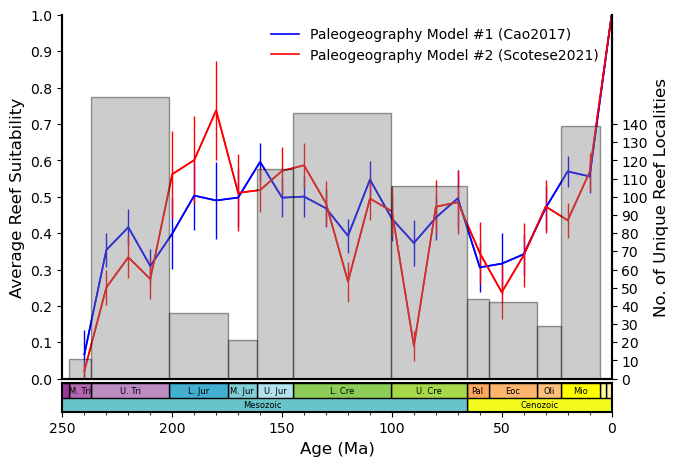

In [346]:
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
ax.errorbar(eByte_probs.keys(), list(zip(*eByte_probs.values()))[0], yerr=list(zip(*eByte_probs.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese2021)')
ax.errorbar(scotese_probs.keys(), list(zip(*scotese_probs.values()))[0], yerr=list(zip(*scotese_probs.values()))[1], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

# ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')
ax.xaxis.set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 200)
ax2.set_yticks(np.arange(0, 141, 10))
ax2.set_ylabel('No. of Unique Reef Localities')

# Histogram with epoch bins
uniqueEpochs = combinedDF.groupby('epoch')
counts = {}
for epoch, group in uniqueEpochs:
    counts[epoch] = len(group)

epochBins = [0] + epochs['Start'].tolist()
ax2.hist(combinedDF['age'], bins=epochBins, color='grey', alpha=0.4, label='Paleogeography Model #1 (Cao2017)', edgecolor='black')


# ax2.hist(list(eByte_probs.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*eByte_probs.values()))[2], color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
# ax2.hist(list(scotese_probs.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*scotese_probs.values()))[2], color='red', alpha=0.5, label='Paleogeography Model #2 (Scotese2021)')

ax2.plot([], [], color='black', linestyle=':', label='No. of Unique Reef Localities')

ax.legend(loc='upper right', ncol=1, frameon=False)
# ax2.legend(loc='lower center', ncol=1, frameon=False)

# Hide the right and top spines
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Add the geolgoical scale under the x axis
# eras = ts.Periods[ts.Eras['Start'] < 252].copy().reset_index(drop=True)
# Create a new axis below the main plot, sharing the x-axis
ax0 = fig.add_axes([ax.get_position().x0, 0.04, ax.get_position().width, 0.06], sharex=ax)
ax0.set_xlim(250,0)
ax0.set_ylim(0, 1)
ax0.yaxis.set_visible(False)
ax0.set_xlabel('Age (Ma)')
for i, epoch in epochs.iterrows():
    rect = Rectangle(
        (epoch['Start'], 0),
        epoch['End'] - epoch['Start'],
        1,
        facecolor=epoch['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (epoch['Start'] + epoch['End']) / 2, 
        0.75, 
        epoch['ShortName'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )
# Add the era names underneath the epochs
for i, era in eras.iterrows():
    rect = Rectangle(
        (era['Start'], 0),
        era['End'] - era['Start'],
        0.5,
        facecolor=era['Color'],
        edgecolor='k',
        alpha=1
    )
    ax0.add_artist(rect)
    ax0.text(
        (era['Start'] + era['End']) / 2, 
        0.25, 
        era['Name'], 
        ha='center', 
        va='center', 
        fontsize=6, 
        rotation=0
    )